In [ ]:

# ── 01_exploration.ipynb ──────────────────────────────────────────────────
# Purpose: Understand the raw dataset before feeding it into the pipeline.
# -------------------------------------------------------------------------

import os, sys
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.data_validation import validate_dataset, detect_optional_columns
from src.preprocessing import clean_dataframe
from src.feature_engineering import create_all_features

# ── Load raw Rossmann files ───────────────────────────────────────────────
train = pd.read_csv("../data/raw/train.csv", parse_dates=["Date"])
store = pd.read_csv("../data/raw/store.csv")

df_raw = train.merge(store, on="Store", how="left")

# Rename to match the platform's standard schema
df_raw = df_raw.rename(columns={
    "Date": "date",
    "Sales": "sales_qty",
    "Store": "store_id",
    "Promo": "is_promotion",
})

print(f"Loaded {len(df_raw):,} rows | columns: {list(df_raw.columns)}")
df_raw.head()


C:\Users\aeshi\AppData\Local\Temp\ipykernel_14832\2720761945.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv", parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:

# ── Data Quality Audit ────────────────────────────────────────────────────

print("=== Shape ===")
print(df_raw.shape)

print("\n=== dtypes ===")
print(df_raw.dtypes)

print("\n=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_cols = missing[missing > 0]
print(missing_cols if not missing_cols.empty else "No missing values detected")

print(f"\n=== Date Range ===")
print(f"  {df_raw['date'].min().date()}  →  {df_raw['date'].max().date()}")
print(f"  Span: {(df_raw['date'].max() - df_raw['date'].min()).days} calendar days")

print(f"\n=== Unique Stores ===  {df_raw['store_id'].nunique()}")

# Open days with zero sales — likely data-entry errors
if "Open" in df_raw.columns:
    open_zero = df_raw[(df_raw["Open"] == 1) & (df_raw["sales_qty"] == 0)]
    print(f"\nOpen days with zero sales (anomalies): {len(open_zero):,}")

print("\n=== Sales Summary Statistics ===")
print(df_raw["sales_qty"].describe().round(2))


(1017209, 18)
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object
Missing values per column:
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers

<Axes: title={'center': 'Total Sales Over Time'}, xlabel='Date'>

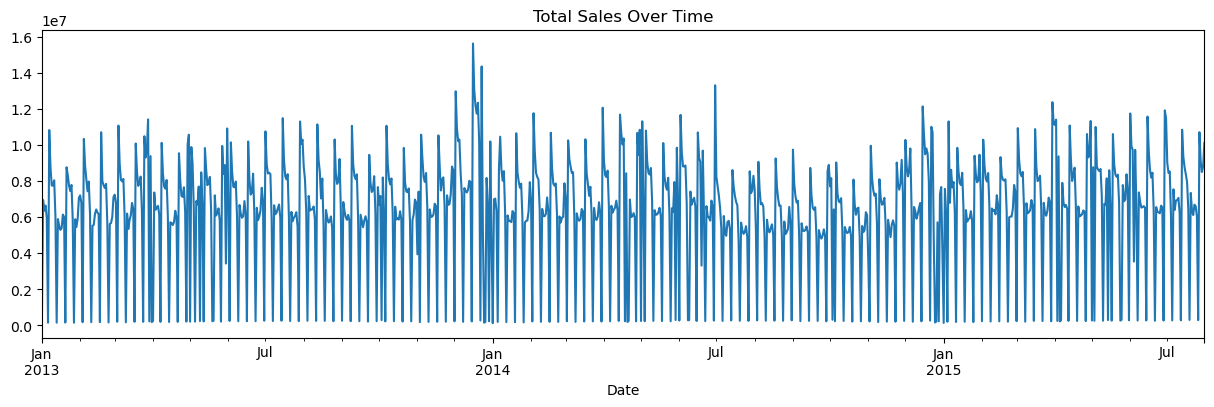

In [ ]:

# ── Total Sales Over Time ─────────────────────────────────────────────────

daily = df_raw.groupby("date")["sales_qty"].sum().reset_index()

fig = px.line(
    daily, x="date", y="sales_qty",
    title="Total Daily Sales Across All Stores",
    labels={"sales_qty": "Total Sales", "date": "Date"},
    template="plotly_white",
)
fig.update_traces(line_color="royalblue", line_width=1.5)
fig.update_layout(hovermode="x unified")
fig.show()



## Total Sales Trend

The daily sum of sales across all stores shows clear **weekly cycles** and a strong **December spike** (holiday season). The series appears non-stationary with a slight upward drift — important context for Prophet's `changepoint_prior_scale` tuning.


<Axes: title={'center': 'Average Sales by Day of Week'}, xlabel='DayOfWeek'>

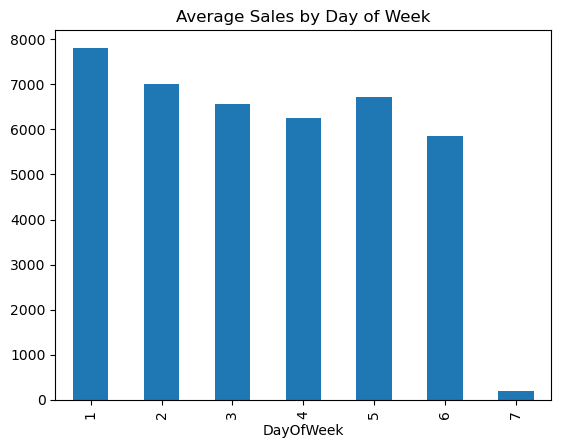

In [ ]:

# ── Day-of-Week Pattern ───────────────────────────────────────────────────

dow_avg = (
    df_raw.groupby(df_raw["date"].dt.dayofweek)["sales_qty"]
    .mean()
    .reset_index()
)
dow_avg.columns = ["dow", "avg_sales"]
dow_avg["day_name"] = dow_avg["dow"].map(
    {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
)

fig = px.bar(
    dow_avg, x="day_name", y="avg_sales",
    title="Average Sales by Day of Week",
    labels={"avg_sales": "Avg Sales", "day_name": "Weekday"},
    color="avg_sales",
    color_continuous_scale="Blues",
    template="plotly_white",
)
fig.show()



## Day-of-Week Pattern

Sunday sales collapse to near-zero because Rossmann stores are closed on Sundays. Saturday is the strongest trading day. This strong weekly seasonality is captured by:
- **Prophet**: `weekly_seasonality=True`
- **XGBoost**: `day_of_week` and `is_weekend` feature columns


<Axes: title={'center': 'Average Sales by Month'}, xlabel='Month'>

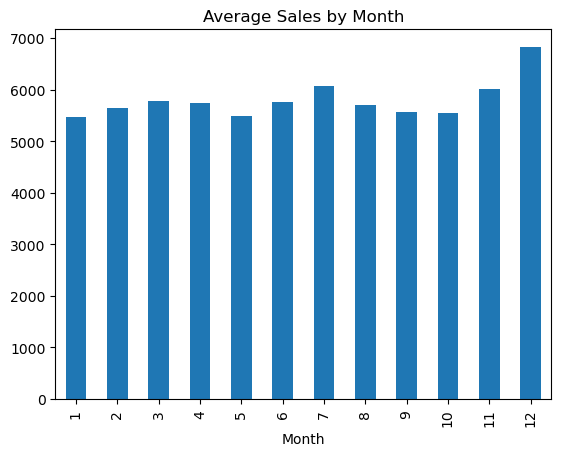

In [ ]:

# ── Monthly Seasonality ───────────────────────────────────────────────────

monthly = (
    df_raw.groupby(df_raw["date"].dt.month)["sales_qty"]
    .mean()
    .reset_index()
)
monthly.columns = ["month", "avg_sales"]
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly["month_name"] = monthly["month"].apply(lambda m: month_names[m - 1])

fig = px.bar(
    monthly, x="month_name", y="avg_sales",
    title="Average Sales by Month",
    labels={"avg_sales": "Avg Sales", "month_name": "Month"},
    color="avg_sales",
    color_continuous_scale="Oranges",
    template="plotly_white",
)
fig.show()



## Monthly Seasonality

December records the **highest average sales**, driven by holiday purchasing. Post-holiday January/February show the steepest dip. Prophet's `yearly_seasonality=True` and XGBoost's `month` + `quarter` features both capture this cycle.


<Axes: title={'center': 'Sales: Promo vs No Promo'}, xlabel='Promo'>

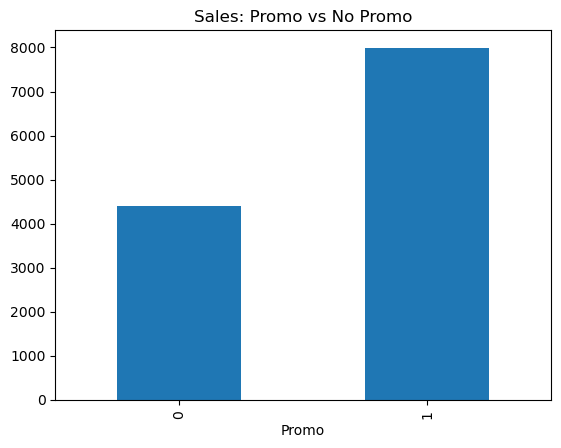

In [ ]:

# ── Promotion Impact ──────────────────────────────────────────────────────

promo_avg = df_raw.groupby("is_promotion")["sales_qty"].mean().reset_index()
promo_avg["label"] = promo_avg["is_promotion"].map({0: "No Promo", 1: "Promo Active"})

fig = px.bar(
    promo_avg, x="label", y="sales_qty",
    title="Average Sales: Promotion vs No Promotion",
    labels={"sales_qty": "Avg Sales", "label": ""},
    color="label",
    color_discrete_map={"No Promo": "lightcoral", "Promo Active": "mediumseagreen"},
    template="plotly_white",
)
fig.show()

lift = (
    promo_avg.set_index("is_promotion")["sales_qty"][1]
    / promo_avg.set_index("is_promotion")["sales_qty"][0]
    - 1
) * 100
print(f"Promotion average sales lift: +{lift:.1f}%")



## Promotion Impact

Promotions produce a substantial average sales lift, confirming that `is_promotion` is a high-value feature and should be included as an additional regressor in both Prophet and XGBoost.


<Axes: xlabel='Store'>

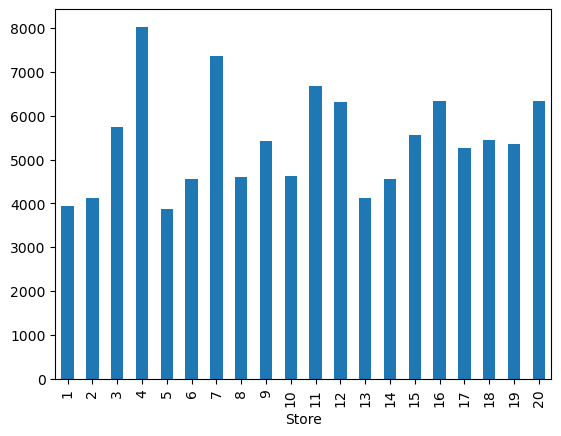

In [ ]:

# ── Store-Level Sales Distribution ────────────────────────────────────────

store_avg = (
    df_raw.groupby("store_id")["sales_qty"]
    .mean()
    .reset_index()
    .rename(columns={"sales_qty": "avg_sales"})
    .sort_values("avg_sales", ascending=False)
)

fig = px.histogram(
    store_avg, x="avg_sales",
    title="Distribution of Average Daily Sales per Store",
    labels={"avg_sales": "Avg Daily Sales"},
    nbins=40,
    template="plotly_white",
    color_discrete_sequence=["steelblue"],
)
fig.show()

print(f"Highest-volume store: {int(store_avg.iloc[0]['store_id'])}  "
      f"→ avg {store_avg.iloc[0]['avg_sales']:.0f} units/day")
print(f"Lowest-volume  store: {int(store_avg.iloc[-1]['store_id'])}  "
      f"→ avg {store_avg.iloc[-1]['avg_sales']:.0f} units/day")


<Axes: title={'center': 'Store 1 Daily Sales'}, xlabel='Date'>

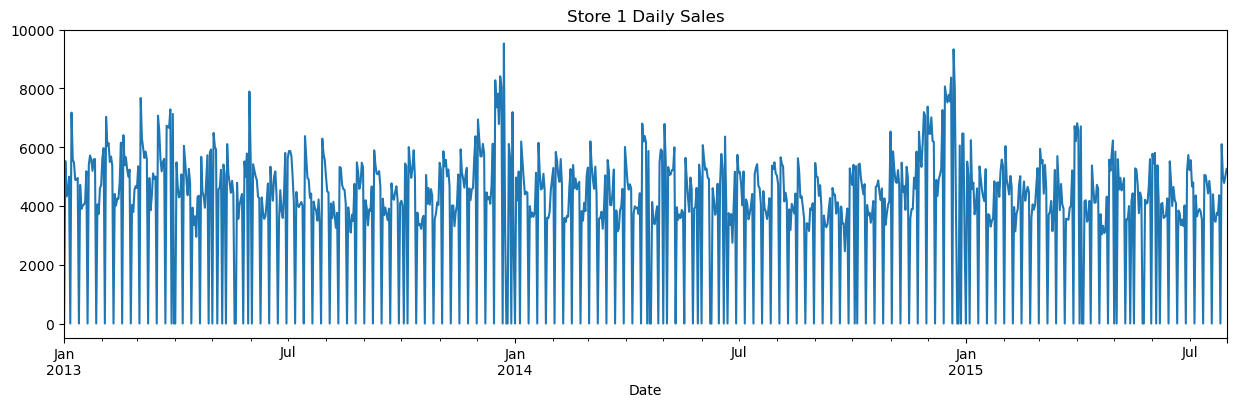

In [ ]:

# ── Single Store Deep-Dive (Store 1) ─────────────────────────────────────

store1 = df_raw[df_raw["store_id"] == 1].sort_values("date")

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Store 1 — Daily Sales Over Time", "Sales Distribution"),
    row_heights=[0.65, 0.35],
)
fig.add_trace(
    go.Scatter(
        x=store1["date"], y=store1["sales_qty"],
        mode="lines", name="Sales",
        line={"color": "royalblue", "width": 1.2},
    ),
    row=1, col=1,
)
fig.add_trace(
    go.Histogram(
        x=store1["sales_qty"], name="Distribution",
        marker_color="lightsteelblue", nbinsx=50, showlegend=False,
    ),
    row=2, col=1,
)
fig.update_layout(
    template="plotly_white", showlegend=False,
    height=580, title_text="Store 1 — Sales Profile",
)
fig.show()

print("Store 1 descriptive stats:")
print(store1["sales_qty"].describe().round(2))


In [ ]:

# ── Outlier Detection ─────────────────────────────────────────────────────
# Flag rows where sales_qty is more than 3 standard deviations above the mean.

mean_s = df_raw["sales_qty"].mean()
std_s  = df_raw["sales_qty"].std()
outliers = df_raw[df_raw["sales_qty"] > mean_s + 3 * std_s]

print(f"Outlier threshold (mean + 3σ): {mean_s + 3*std_s:,.0f}")
print(f"Outlier rows: {len(outliers):,} ({100*len(outliers)/len(df_raw):.2f}% of data)\n")

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_raw["date"], y=df_raw["sales_qty"],
    mode="markers", name="Normal",
    marker={"color": "steelblue", "size": 2, "opacity": 0.4},
))
fig.add_trace(go.Scatter(
    x=outliers["date"], y=outliers["sales_qty"],
    mode="markers", name="Outlier (>3σ)",
    marker={"color": "crimson", "size": 5},
))
fig.update_layout(
    title="Sales Outliers (3σ Rule)",
    xaxis_title="Date", yaxis_title="Sales Qty",
    template="plotly_white", hovermode="closest",
)
fig.show()


In [ ]:

# ── Correlation Analysis ─────────────────────────────────────────────────
# Compute Pearson correlation between numeric columns and sales_qty.

numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr = df_raw[numeric_cols].corr()["sales_qty"].drop("sales_qty").sort_values()

fig = px.bar(
    x=corr.values, y=corr.index,
    orientation="h",
    title="Feature Correlation with Sales Qty",
    labels={"x": "Pearson r", "y": "Feature"},
    color=corr.values,
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    template="plotly_white",
)
fig.update_layout(yaxis={"categoryorder": "total ascending"})
fig.show()

print("Top 5 positive correlators:")
print(corr.tail(5))
print("\nTop 5 negative correlators:")
print(corr.head(5))


In [ ]:

## Exploration Summary

| Finding | Implication |
|---|---|
| Strong weekly cycle (Sunday ≈ 0) | Prophet weekly seasonality essential |
| December holiday spike | Prophet yearly seasonality essential |
| Promotion lifts sales significantly | `is_promotion` must be a regressor |
| ~2% outlier rows (>3σ) | `remove_closed_store_days` handles zero-blocks |
| Missing values in some store columns | Validation step drops/fills before training |

→ Proceed to **02_model_experiments.ipynb** to train and compare models.
